# Machine Learning Basics

----

This lab focuses on the practical applications of machine learning using widely available datasets. 

We will be using common Python libraries like [**SciKit-Learn**](https://scikit-learn.org/stable/index.html) and [**pytorch**](https://pytorch.org/) to  train and evaluate machine learning models on widely available datasets. This course assumes knowledge of other common python libraries like numpy, pandas and matplotlib. 

# Environment Setup

[**Jupyter Notebooks**](https://jupyter.org/) provide an interactive coding environment and will be used to write and run all code for this lab. You will need to ensure the dependencies for this module are installed using conda. Please see the instructions in README.md. 


To run this Jupyter Notebook:
    Activate conda environment: `conda activate ai4dd`
    Run Jupyter: `jupyter notebook`

The notebook should now be running at localhost:8888. 

----

# Intro to Machine Learning

Machine learning is the sub-category of artificial intelligence concerned with using existing data to make accurate predictions. Machine learning is often split into **supervised learning**, which aims to predict known outcomes from labelled data, and **unsupervised** learning, which aims to find unknown relationships within unlabelled data. This notebook focuses on regression and classification tasks, that are both types of **supervised learning**. 

Machine learning pipelines typically follow these steps:
1. Spilt data into training and testing sets.
2. Use the training set to fit the model.
3. Use the test set to evaluate the model fit. 

# Linear Regression

The simplest type of machine learning algorithm is Linear Regression, which allows you to predict an outcome *y* from an observed variable *x*.

*y = mx + c*

Let's see how we can use [**SciKit-Learn**](https://scikit-learn.org/stable/index.html) to train a linear regression model. First, lets simulate some linear data using NumPy

In [5]:
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import numpy as np

# generate random data
x = np.random.uniform(0., 1., size=50)
y = 2 * x + np.random.normal(scale=0.1, size=50)

Next we need to split our data into train and test sets. 

**train set**: what our model sees during training. 

**test set**: what we will use to evaluate our model. 

We will use an 80: 20 train: test split


In [6]:
# split the data into the training and testing sets
x_train = x[:40].reshape(-1, 1)
y_train = y[:40]

x_test = x[40:].reshape(-1, 1)
y_test = y[40:]

Next, we train the model. We have already imported the LinearRegression class from SciKit-Learn's linear_model module. Now we can initialise the model and fit our training data. All SciKit-Learn models can be fit by calling the <model>.fit() function. 

In [7]:
model = LinearRegression() # initialise the model
model.fit(x_train, y_train) # train the model

LinearRegression()

Now our model is trained, we can plot our training data and visualise our linear fit. We can do this by using our trained model to predict *y* values for a series of *x* values denoted by x_range.

We will also plot our test data to see how good the linear fit is.

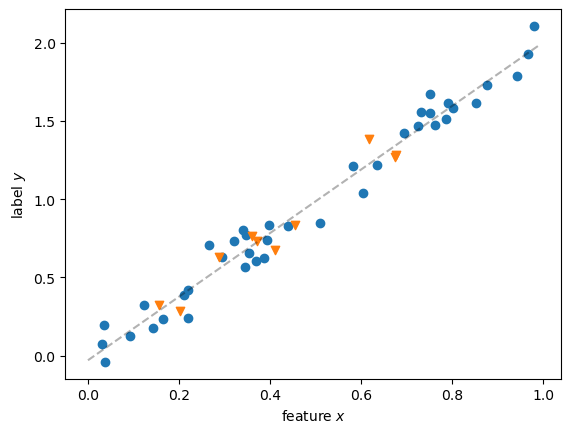

In [9]:
x_range = np.arange(0., 1., 0.01)  # construct the x points for the line
y_pred = model.predict(x_range.reshape(-1, 1))

# plot everything
plt.plot(x_range, y_pred, c='k', ls='--', alpha=0.3)
plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test, marker='v')
plt.xlabel('feature $x$')
plt.ylabel('label $y$')
plt.show()

We can see that the linear fit generally fits the trend of our training data, but how good is this fit and how good is our model at making predictions? 

We can answer these questions quantitatively using the following performance metrics:
1. R² (Coefficient of Determination)

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

2. MAE (Mean Absolute Error)

$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

3. RMSE (Root Mean Squared Error)

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$